In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score ,recall_score ,f1_score,confusion_matrix, mean_squared_error
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [6]:
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [7]:
df.tail(10)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99990,Male,39.0,0,0,No Info,27.32,6.1,100,0
99991,Male,22.0,0,0,current,29.65,6.0,80,0
99992,Female,26.0,0,0,never,34.34,6.5,160,0
99993,Female,40.0,0,0,never,40.69,3.5,155,0
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [9]:
df.shape

df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [10]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [11]:
calculezero = (df['diabetes'] == 0).sum()
calculeone = (df['diabetes'] == 1).sum()

print(f"0': {calculezero}")
print(f"1': {calculeone}")

#grannd desequilibre entre les 0 et 1   dans le dataset  on doit le regler (class impalance )  


0': 91500
1': 8500


In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(96146, 9)

In [14]:
df.duplicated().sum()

0

In [15]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [16]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [17]:
df = df[df['age'] >= 7]


In [18]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,89115.000000,89115.000000,89115.000000,89115.000000,89115.000000,89115.000000,89115.000000
mean,44.851821,0.083712,0.043999,28.016222,5.542170,138.652000,0.095046
std,20.403602,0.276957,0.205095,6.427652,1.080259,41.352822,0.293280
min,7.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,28.000000,0.000000,0.000000,24.400000,4.800000,100.000000,0.000000
50%,45.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,61.000000,0.000000,0.000000,30.350000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [19]:
df.head(5)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [20]:

columns_to_check = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

outlier_counts = {}

for column in columns_to_check:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_counts[column] = outliers.shape[0]  # Number of outliers in this column

total_outliers = sum(outlier_counts.values())
print("Outliers per column:", outlier_counts)
print("Total number of outliers across specified columns:", total_outliers)

Outliers per column: {'age': 0, 'bmi': 5969, 'HbA1c_level': 1309, 'blood_glucose_level': 2028}
Total number of outliers across specified columns: 9306


In [21]:

columns_to_check = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for column in columns_to_check:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep only rows that are within bounds
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# After executing, 'data' will have rows with outliers removed
print("Data after removing outliers using IQR:", df.shape)


Data after removing outliers using IQR: (80573, 9)


In [22]:
categorical_feautres = ['gender','smoking_history']
categorical_feautres


['gender', 'smoking_history']

In [23]:
df['gender'].unique()


array(['Female', 'Male', 'Other'], dtype=object)

In [24]:
df['gender'].value_counts()


gender
Female    47430
Male      33126
Other        17
Name: count, dtype: int64

In [25]:
df = df[df['gender'] != 'Other']


In [26]:
df['gender'].value_counts()

gender
Female    47430
Male      33126
Name: count, dtype: int64

In [27]:
df['smoking_history'].value_counts()

smoking_history
never          30265
No Info        24728
current         8289
former          8093
not current     5619
ever            3562
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80556 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               80556 non-null  object 
 1   age                  80556 non-null  float64
 2   hypertension         80556 non-null  int64  
 3   heart_disease        80556 non-null  int64  
 4   smoking_history      80556 non-null  object 
 5   bmi                  80556 non-null  float64
 6   HbA1c_level          80556 non-null  float64
 7   blood_glucose_level  80556 non-null  int64  
 8   diabetes             80556 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.1+ MB


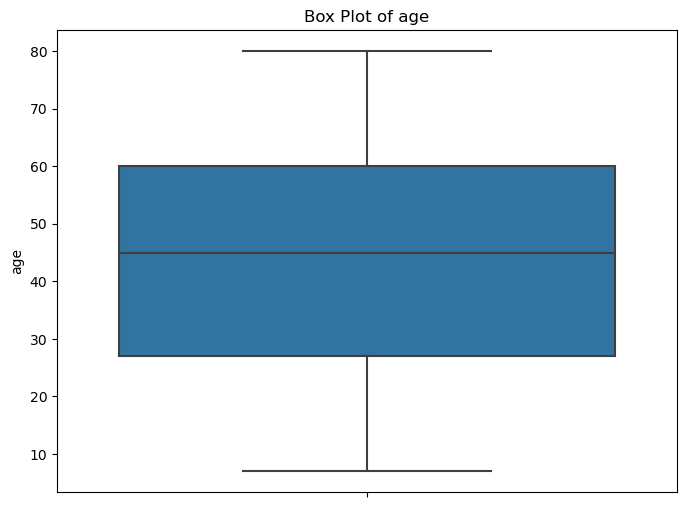

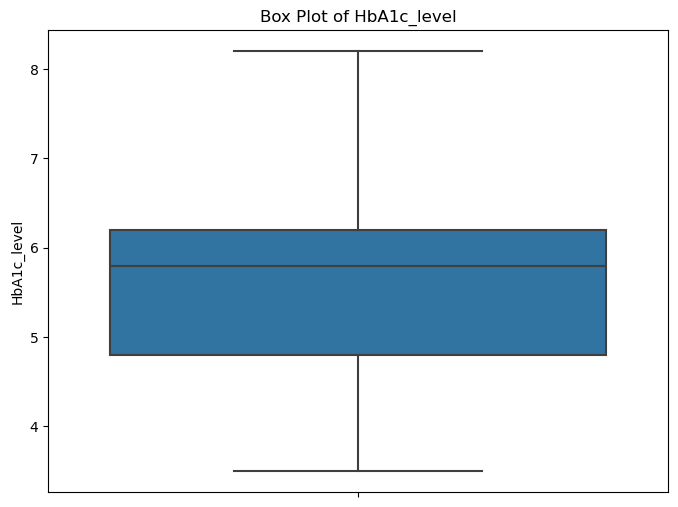

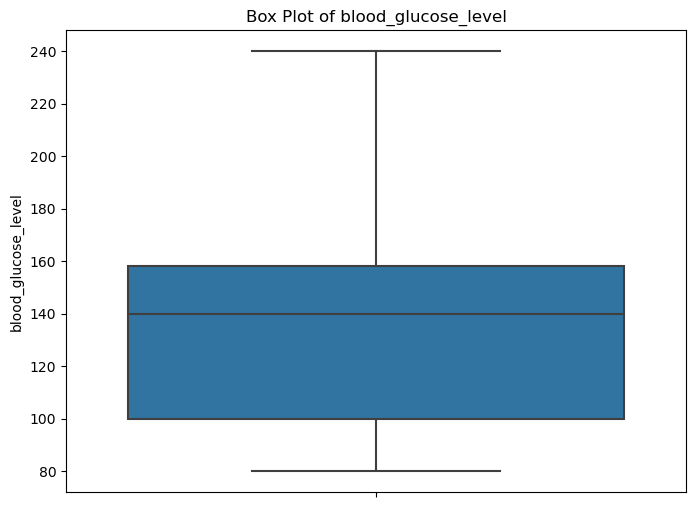

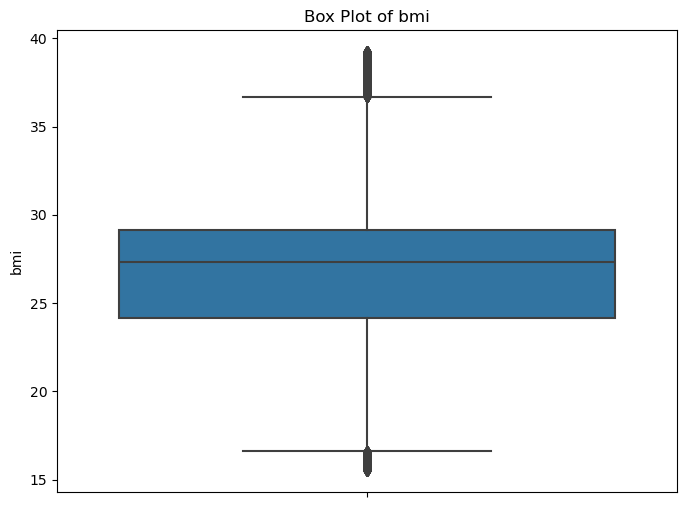

In [29]:
features = ['age', 'HbA1c_level', 'blood_glucose_level', 'bmi']
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=feature, data=df)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.show()

In [30]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_count = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)].shape[0]

print(f'Number of outliers in bmi: {outliers_count}')


Number of outliers in bmi: 3662


In [31]:
df.shape

(80556, 9)

ENCODAGE DES COLONNES POUR QUE LES ALGORITHMES PUISSE COMPRENDRE




In [32]:
columns_to_encode = ['gender','smoking_history']

In [33]:
ohe= OneHotEncoder(sparse_output = False).set_output(transform='pandas')

In [34]:
ohe_trans = ohe.fit_transform(df[['gender','smoking_history']]).astype(int)

In [35]:
ohe_trans

,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1,0,0,0,0,0,1,0
1,1,0,1,0,0,0,0,0
2,0,1,0,0,0,0,1,0
3,1,0,0,1,0,0,0,0
4,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
99992,1,0,0,0,0,0,1,0
99994,1,0,1,0,0,0,0,0
99997,0,1,0,0,0,1,0,0
99998,1,0,0,0,0,0,1,0


In [36]:
df['gender'].unique()


array(['Female', 'Male'], dtype=object)

In [37]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [38]:
df = df.drop(['gender', 'smoking_history'], axis=1)

In [39]:
df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...
99992,26.0,0,0,34.34,6.5,160,0
99994,36.0,0,0,24.60,4.8,145,0
99997,66.0,0,0,27.83,5.7,155,0
99998,24.0,0,0,35.42,4.0,100,0


In [40]:

finaldata = pd.concat([df, ohe_trans], axis=1, ignore_index=False)
finaldata


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99992,26.0,0,0,34.34,6.5,160,0,1,0,0,0,0,0,1,0
99994,36.0,0,0,24.60,4.8,145,0,1,0,1,0,0,0,0,0
99997,66.0,0,0,27.83,5.7,155,0,0,1,0,0,0,1,0,0
99998,24.0,0,0,35.42,4.0,100,0,1,0,0,0,0,0,1,0


In [41]:
numeric_columns = finaldata.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
finaldata[numeric_columns] = scaler.fit_transform(finaldata[numeric_columns])

In [42]:
finaldata.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1.000000,0.0,1.0,0.408155,0.659574,0.37500,0.0,1,0,0,0,0,0,1,0
1,0.643836,0.0,0.0,0.497688,0.659574,0.00000,0.0,1,0,1,0,0,0,0,0
2,0.287671,0.0,0.0,0.497688,0.468085,0.48750,0.0,0,1,0,0,0,0,1,0
3,0.397260,0.0,0.0,0.335015,0.319149,0.46875,0.0,1,0,0,1,0,0,0,0
4,0.945205,1.0,1.0,0.195881,0.276596,0.46875,0.0,0,1,0,1,0,0,0,0


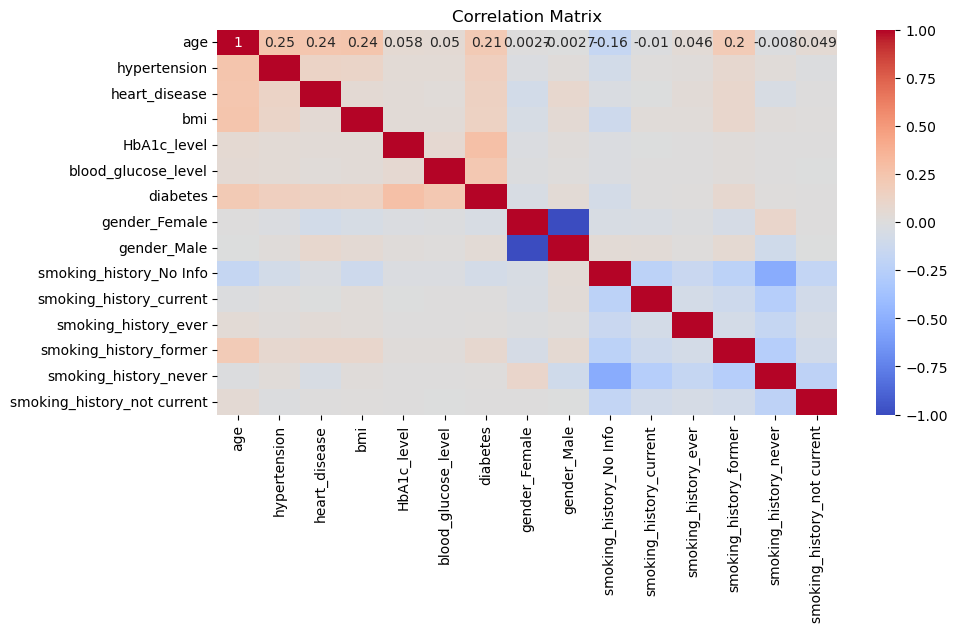

In [44]:
correlation_matrix = finaldata.corr()


plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [45]:
correlation = finaldata.corr()
correlation

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
age,1.000000,0.249863,0.237580,0.243596,0.058039,0.049564,0.209915,0.002670,-0.002670,-0.164409,-0.010309,0.046180,0.202617,-0.008028,0.048865
hypertension,0.249863,1.000000,0.118067,0.115375,0.043833,0.039524,0.157387,-0.021742,0.021742,-0.085907,0.011128,0.018547,0.071888,0.027081,-0.009017
heart_disease,0.237580,0.118067,1.000000,0.049455,0.037654,0.029382,0.142258,-0.085803,0.085803,-0.026935,-0.000972,0.034163,0.086723,-0.043441,0.002604
bmi,0.243596,0.115375,0.049455,1.000000,0.038801,0.032570,0.133641,-0.050143,0.050143,-0.115900,0.025491,0.024751,0.087924,0.021443,0.014948
HbA1c_level,0.058039,0.043833,0.037654,0.038801,1.000000,0.062838,0.274373,-0.016476,0.016476,-0.020904,-0.001163,0.005255,0.020852,0.003346,0.004025
blood_glucose_level,0.049564,0.039524,0.029382,0.032570,0.062838,1.000000,0.225841,-0.010158,0.010158,-0.019808,0.003912,0.000569,0.016932,0.006739,-0.002054
diabetes,0.209915,0.157387,0.142258,0.133641,0.274373,0.225841,1.000000,-0.041703,0.041703,-0.071503,0.004670,0.014820,0.075589,0.008188,0.007165
gender_Female,0.002670,-0.021742,-0.085803,-0.050143,-0.016476,-0.010158,-0.041703,1.000000,-1.000000,-0.041374,-0.032170,-0.012670,-0.055642,0.095406,0.007787
gender_Male,-0.002670,0.021742,0.085803,0.050143,0.016476,0.010158,0.041703,-1.000000,1.000000,0.041374,0.032170,0.012670,0.055642,-0.095406,-0.007787
smoking_history_No Info,-0.164409,-0.085907,-0.026935,-0.115900,-0.020904,-0.019808,-0.071503,-0.041374,0.041374,1.000000,-0.225398,-0.143149,-0.222416,-0.516290,-0.182243


CREATION DE MODELE ML

In [46]:
X = finaldata.drop(columns=['diabetes'])#'HbA1c_level','blood_glucose_level'	
Y = finaldata['diabetes']

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [48]:
#from imblearn.over_sampling import RandomOverSampler
#ros = RandomOverSampler(random_state=42)
#X_train_resampled, Y_train_resampled = ros.fit_resample(X_train, Y_train)

from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, k_neighbors=5)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)


In [49]:

print(y_resampled.value_counts())


NameError: name 'y_resampled' is not defined

In [50]:
model2 = LogisticRegression()
model2.fit(X_resampled,y_resampled)
y_pred = model2.predict(X_resampled)
print("Classification Report:\n", classification_report(y_resampled, y_pred))

NameError: name 'X_resampled' is not defined

In [51]:
model2 = LogisticRegression(class_weight='balanced')
model2.fit(X_train_balanced, Y_train_balanced)
y_pred = model2.predict(X_test)
print("Classification Report on Original Test Set:\n", classification_report(Y_test, y_pred))

Classification Report on Original Test Set:
               precision    recall  f1-score   support

         0.0       0.99      0.84      0.91     15240
         1.0       0.24      0.86      0.37       872

    accuracy                           0.84     16112
   macro avg       0.61      0.85      0.64     16112
weighted avg       0.95      0.84      0.88     16112



In [ ]:
import lazypredict
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models_train, predictions_train = clf.fit(X_resampled, X_resampled, y_resampled, y_resampled)
models_train

 97%|█████████▋| 28/29 [1:05:49<03:47, 227.50s/it]

[LightGBM] [Info] Number of positive: 75983, number of negative: 75983
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 393
[LightGBM] [Info] Number of data points in the train set: 151966, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


100%|██████████| 29/29 [1:05:51<00:00, 136.26s/it]


In [ ]:
models_test, predictions_test = clf.fit(X_resampled, X_test, y_resampled, Y_test)
models_test

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


 97%|█████████▋| 28/29 [41:36<02:20, 140.22s/it]  

[LightGBM] [Info] Number of positive: 75983, number of negative: 75983
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 393
[LightGBM] [Info] Number of data points in the train set: 151966, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


100%|██████████| 29/29 [41:37<00:00, 86.11s/it] 


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,1.00,1.00,1.00,1.00,10.60
DecisionTreeClassifier,1.00,1.00,1.00,1.00,0.43
ExtraTreeClassifier,1.00,1.00,1.00,1.00,0.19
ExtraTreesClassifier,1.00,1.00,1.00,1.00,8.03
BaggingClassifier,1.00,1.00,1.00,1.00,2.34
KNeighborsClassifier,0.97,0.97,0.97,0.97,16.25
XGBClassifier,0.93,0.93,0.93,0.93,1.00
LGBMClassifier,0.91,0.91,0.91,0.91,1.04
AdaBoostClassifier,0.89,0.89,0.89,0.89,3.78


In [54]:
import xgboost as xgb
model = xgb.XGBClassifier()

model.fit(X_train_balanced, Y_train_balanced)

y_pred = model.predict(X_test)
print("Classification Report on Original Test Set:\n", classification_report(Y_test, y_pred))

Classification Report on Original Test Set:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     15240
         1.0       0.85      0.53      0.65       872

    accuracy                           0.97     16112
   macro avg       0.91      0.76      0.82     16112
weighted avg       0.97      0.97      0.97     16112



In [56]:
# Step 3: Train the model on the resampled training data
model2 = LogisticRegression()
model2.fit(X_train_balanced, Y_train_balanced)

# Step 4: Evaluate the model on the original (imbalanced) test set
y_pred = model2.predict(X_test)

# Step 5: Print classification report
print("Classification Report on Original Test Set:\n", classification_report(Y_test, y_pred))

Classification Report on Original Test Set:
               precision    recall  f1-score   support

         0.0       0.98      0.91      0.94     15240
         1.0       0.32      0.74      0.44       872

    accuracy                           0.90     16112
   macro avg       0.65      0.82      0.69     16112
weighted avg       0.95      0.90      0.92     16112



In [86]:

model_xgb = xgb.XGBClassifier(scale_pos_weight=1, random_state=42)

# Entraînement du modèle sur les données équilibrées
model_xgb.fit(X_train_balanced, Y_train_balanced)

# Prédictions sur les données de test
y_pred_xgb = model_xgb.predict(X_test)

# Rapport de classification
print("Classification Report on Test Set (XGBoost):\n", classification_report(Y_test, y_pred_xgb))

Classification Report on Test Set (XGBoost):
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     15240
         1.0       0.85      0.53      0.65       872

    accuracy                           0.97     16112
   macro avg       0.91      0.76      0.82     16112
weighted avg       0.97      0.97      0.97     16112

